In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import os

print("--- Step 1: Loading and Preparing ISOT Dataset ---")

# --- 1. Define File Paths ---
base_path = '/content/'
fake_path = os.path.join(base_path, 'Fake.csv')
real_path = os.path.join(base_path, 'True.csv')

# --- 2. Load Data (using 'engine=python' to skip errors) ---
df_fake = pd.read_csv(fake_path, on_bad_lines='skip', engine='python')
df_real = pd.read_csv(real_path, on_bad_lines='skip', engine='python')

print(f"Loaded {len(df_fake)} fake articles.")
print(f"Loaded {len(df_real)} real articles.")

# --- 3. Label and Combine ---
df_fake['label'] = 1  # 1 for 'fake'
df_real['label'] = 0  # 0 for 'real'

df_combined = pd.concat([df_fake, df_real], ignore_index=True)
df_combined['full_text'] = df_combined['title'] + " " + df_combined['text']
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)
df_combined = df_combined.dropna(subset=['full_text'])

print(f"Total articles: {len(df_combined)}")

# --- 4. Clean Text (Removing Data Leakage) ---
def clean_text(text):
    text = str(text).lower()
    # Remove reuters tags and other source info
    text = re.sub(r'\(reuters\)|(washington|london|moscow|etc) -', '', text)
    # General cleaning
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

print("Cleaning data...")
df_combined['cleaned_text'] = df_combined['full_text'].apply(clean_text)

# --- 5. Tokenize and Pad Sequences ---
VOCAB_SIZE = 10000
MAX_LENGTH = 300
EMBEDDING_DIM = 64

labels = df_combined['label'].values
articles = df_combined['cleaned_text'].values

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(articles)

# Convert text to numerical sequences
sequences = tokenizer.texts_to_sequences(articles)

# Pad sequences
padded_sequences = pad_sequences(sequences, maxlen=MAX_LENGTH,
                                 padding='post', truncating='post')

print(f"\nShape of padded sequences tensor: {padded_sequences.shape}")

# --- 6. Split into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42
)

print("\n--- DATA IS CLEAN AND READY ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

--- Step 1: Loading and Preparing ISOT Dataset ---
Loaded 1201 fake articles.
Loaded 1217 real articles.
Total articles: 2418
Cleaning data...

Shape of padded sequences tensor: (2418, 300)

--- DATA IS CLEAN AND READY ---
X_train shape: (1934, 300)
y_train shape: (1934,)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Attention
)
from tensorflow.keras.callbacks import EarlyStopping

print("\n--- Step 2: Building and Training the Model ---")

# --- 1. Define Model Parameters ---
VOCAB_SIZE = 10000
MAX_LENGTH = 300
EMBEDDING_DIM = 64

# --- 2. Define Model Architecture ---
input_layer = Input(shape=(MAX_LENGTH,), name="input_layer")
embedding_layer = Embedding(input_dim=VOCAB_SIZE,
                            output_dim=EMBEDDING_DIM,
                            name="embedding_layer")(input_layer)
conv_layer = Conv1D(filters=32, kernel_size=5, activation='relu',
                    name="convolutional_layer")(embedding_layer)
pool_layer = MaxPooling1D(pool_size=2, name="pooling_layer")(conv_layer)
bilstm_layer = Bidirectional(
    LSTM(32, return_sequences=True), name="bilstm_layer"
)(pool_layer)
attention_result = Attention(name="attention_layer")([bilstm_layer, bilstm_layer])
final_lstm = Bidirectional(
    LSTM(16, return_sequences=False), name="final_lstm_layer"
)(attention_result)
dropout_layer = Dropout(0.5, name="dropout_layer")(final_lstm)
dense_layer = Dense(32, activation='relu', name="dense_layer")(dropout_layer)
output_layer = Dense(1, activation='sigmoid', name="output_layer")(dense_layer)

model = Model(inputs=input_layer, outputs=output_layer)

# --- 3. Compile Model ---
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

# --- 4. Train Model ---
print("\n--- Starting Model Training ---")

early_stopping = EarlyStopping(monitor='val_accuracy', patience=2,
                               restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5. Evaluate Model ---
print("\n--- Training Complete. Evaluating Model... ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")


--- Step 2: Building and Training the Model ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 300, 64)   │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convolutional_layer │ (None, 296, 32)   │     10,272 │ embedding_layer[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_layer       │ (None, 148, 32)   │          0 │ convolutional_la… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_layer        │ (None, 148, 64)   │     16,640 │ pooling_layer[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 148, 64)   │          0 │ bilstm_layer[0][… │
│ (Attention)         │                   │            │ bilstm_layer[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_lstm_layer    │ (None, 32)        │     10,368 │ attention_layer[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_layer       │ (None, 32)        │          0 │ final_lstm_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_layer (Dense) │ (None, 32)        │      1,056 │ dropout_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 1)         │         33 │ dense_layer[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 678,369 (2.59 MB)

 Trainable params: 678,369 (2.59 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Model Training ---
Epoch 1/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6369 - loss: 0.6334 - val_accuracy: 0.9504 - val_loss: 0.1788
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9629 - loss: 0.1332 - val_accuracy: 0.9855 - val_loss: 0.0617
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9859 - loss: 0.0490 - val_accuracy: 0.9917 - val_loss: 0.0279
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9973 - loss: 0.0162 - val_accuracy: 0.9855 - val_loss: 0.0352
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9983 - loss: 0.0081 - val_accuracy: 0.9938 - val_loss: 0.0285

--- Training Complete. Evaluating Model... ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9893 - loss: 0.0524
Test Accuracy: 99.38%
Test Loss: 0.0285


--- Generating Training Plots ---


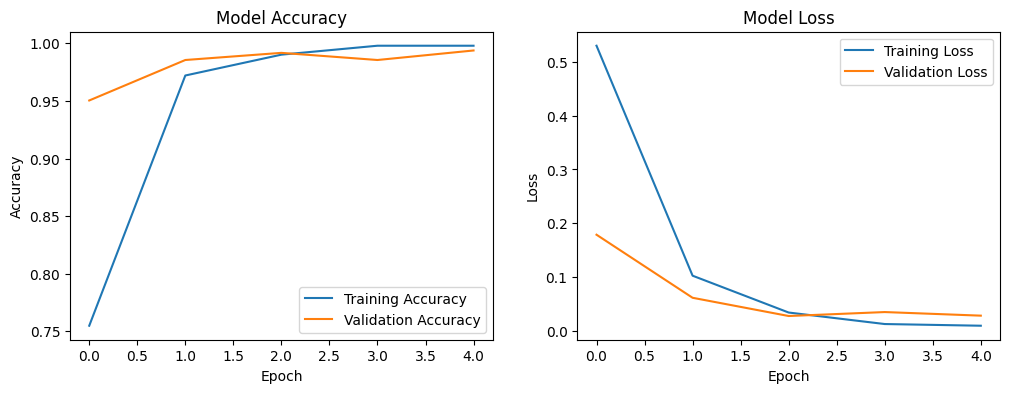

In [3]:
import matplotlib.pyplot as plt

print("--- Generating Training Plots ---")

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [4]:
from sklearn.metrics import classification_report
import numpy as np

print("\n--- Generating Classification Report ---")

# Get probabilities for the test set
y_pred_probs = model.predict(X_test)

# Convert probabilities (e.g., 0.98) to binary classes (1)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# Generate the report
report = classification_report(y_test, y_pred_classes, target_names=['Real (0)', 'Fake (1)'])

print(report)


--- Generating Classification Report ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99       241
    Fake (1)       1.00      0.99      0.99       243

    accuracy                           0.99       484
   macro avg       0.99      0.99      0.99       484
weighted avg       0.99      0.99      0.99       484



In [ ]:
import numpy as np
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text


new_article_text = """
(EXCLUSIVE) Top Scientist CONFIRMS Election Was Stolen!
In a shocking turn of events, a scientist who wished to remain anonymous
has come forward with PROOF of a massive conspiracy. He claims
"The votes were switched, millions of them. I saw it with my own eyes."
This is the bombshell report the media doesn't want you to see!
Share this before they take it down!
"""



# a. Clean the text
cleaned_article = clean_text(new_article_text)

sequences = tokenizer.texts_to_sequences([cleaned_article])

# c. Pad the sequence
# 'MAX_LENGTH' must also be in memory (it was 300)
padded_article = pad_sequences(sequences, maxlen=MAX_LENGTH,
                              padding='post', truncating='post')

# --- 4. Make a prediction ---
prediction = model.predict(padded_article)

# --- 5. Interpret the result ---
# The output is a probability (0 to 1)
raw_score = prediction[0][0]

if raw_score > 0.5:
    print(f"Result: FAKE NEWS (Score: {raw_score * 100:.2f}%)")
else:
    print(f"Result: REAL NEWS (Score: {(1 - raw_score) * 100:.2f}%)")

print(f"(Raw probability: {raw_score})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Result: FAKE NEWS (Score: 100.00%)
(Raw probability: 0.9999940395355225)


In [ ]:
import numpy as np
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Redefine the cleaning function (just in case) ---
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'\(reuters\)|(washington|london|moscow|etc) -', '', text)
    # General cleaning
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# --- 2. Define your new article (A REAL ONE) ---
new_article_text = """
The nation's central bank signaled on Wednesday that it may
continue with its current monetary policy, citing recent
data showing moderate economic growth.

In a press release, officials noted that inflation remains
below their 2% target. They also stated that the labor market
has shown signs of continued strengthening. The committee
voted unanimously to maintain the federal funds rate at its
current level.
"""

# --- 3. Process the new article ---


cleaned_article = clean_text(new_article_text)
sequences = tokenizer.texts_to_sequences([cleaned_article])
padded_article = pad_sequences(sequences, maxlen=MAX_LENGTH,
                              padding='post', truncating='post')

# --- 4. Make a prediction ---
prediction = model.predict(padded_article)

# --- 5. Interpret the result ---
raw_score = prediction[0][0]

if raw_score > 0.5:
    print(f"Result: FAKE NEWS (Score: {raw_score * 100:.2f}%)")
else:
    print(f"Result: REAL NEWS (Score: {(1 - raw_score) * 100:.2f}%)")

print(f"(Raw probability: {raw_score})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Result: REAL NEWS (Score: 99.87%)
(Raw probability: 0.0012862294679507613)
